<a href="https://colab.research.google.com/drive/1RXvYowbs6y8ofcOgoYJp4Zb3S1xcnLgg?usp" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Copyright

<PRE>
Jelen Jupyter notebook a Budapesti Műszaki és Gazdaságtudományi Egyetemen tartott "Deep Learning a gyakorlatban Python és LUA alapon" tantárgy segédanyagaként készült.
A tantárgy honlapja: http://smartlab.tmit.bme.hu/oktatas-deep-learning
Deep Learning kutatás: http://smartlab.tmit.bme.hu/deep-learning

A notebook bármely részének újra felhasználása, publikálása csak a szerzők írásos beleegyezése esetén megegengedett.

2021 (c) Gyires-Tóth Bálint (toth.b kukac tmit pont bme pont hu), Zainkó Csaba (zainko kukac tmit pont bme pont hu), Kalapos András
</PRE>

# MNIST adatbázis tanítása MLP-vel

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD

Ezt követően töltsük be az MNIST adatbázist:

In [2]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [4]:
print(X_train.shape)
print(X_test.shape)
print(X_train.min(), X_train.max())
print(y_train.shape)
print(y_test.shape)
print(y_train[0])

(60000, 28, 28)
(10000, 28, 28)
0 255
(60000,)
(10000,)
5


In [5]:
# Print and try to interpret X_train[0]
print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [6]:
print(np.ceil(X_train[0]/255).astype(int))

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 

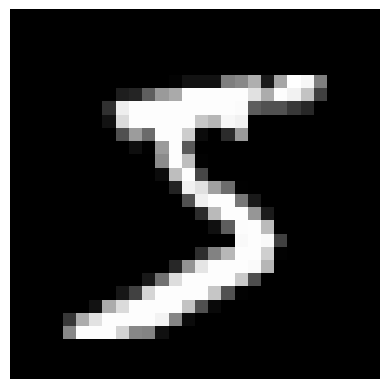

In [7]:
plt.imshow(X_train[0], cmap='gray')
plt.axis('off')
plt.show()

In [8]:
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# [0, 255] tartományba eső pixel értékek átskálázása [0, 1] intervallumba
X_train /= 255
X_test /= 255

# a kimenetet onehot kódolásúvá alakítjuk -> tf.keras.utils.to_categorical
y_tain_cat = to_categorical(y_train, num_classes=None)

nb_classes = y_tain_cat.shape[-1]
#nb_classes = 10

Fontos: a teszt adatbázis címkéit eredeti indexes formában fogjuk használni, nem szükséges `y_test` kategorikussá alakítása.

In [9]:
print(X_train.shape)
print(X_test.shape)
print(y_tain_cat.shape)
print(y_test.shape, "<- a teszt adatbázis címkéit eredeti indexes formában fogjuk használni")
print(np.asarray(range(nb_classes)))
print(y_tain_cat[0].astype(np.int8))


(60000, 784)
(10000, 784)
(60000, 10)
(10000,) <- a teszt adatbázis címkéit eredeti indexes formában fogjuk használni
[0 1 2 3 4 5 6 7 8 9]
[0 0 0 0 0 1 0 0 0 0]


Hozzuk létre a hálózatot:

In [23]:
nb_classes = 10

# Háló definiálása
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=256, input_shape=(784,), activation='relu'))
model.add(Dense(units=256, activation='relu'))
model.add(Dense(units=nb_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer=SGD(learning_rate=0.001),
              metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Majd tanítsuk be a modellünket. Most nem határoztunk meg külön validációs adatbázist, hanem a model.fit függvény validation_split paramétereként adjuk meg, hogy hány százalékot használjon fel validációs célokra a tanítás:

In [11]:
from tensorflow.keras.callbacks import TensorBoard
tb = TensorBoard(log_dir='logs', histogram_freq=1, write_graph=1)

In [24]:
network_history = model.fit(X_train, y_tain_cat, batch_size=128,
                            epochs=30, verbose=1, validation_split=0.2, callbacks=[tb])

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.2536 - loss: 2.2044 - val_accuracy: 0.4137 - val_loss: 2.0917
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5044 - loss: 1.9914 - val_accuracy: 0.5962 - val_loss: 1.8750
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6332 - loss: 1.7719 - val_accuracy: 0.6938 - val_loss: 1.6452
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7070 - loss: 1.5449 - val_accuracy: 0.7453 - val_loss: 1.4152
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7473 - loss: 1.3294 - val_accuracy: 0.7757 - val_loss: 1.2076
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7755 - loss: 1.1449 - val_accuracy: 0.8011 - val_loss: 1.0373
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7960 - loss: 0.9982 - val_accuracy: 0.8198 - val_loss: 0.9053
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8114 - loss: 0.8856 - val_accuracy: 0.

Ezután jelenítsük meg, a tanítás során a hibát és a pontosságot a tanító és validációs adatokon:

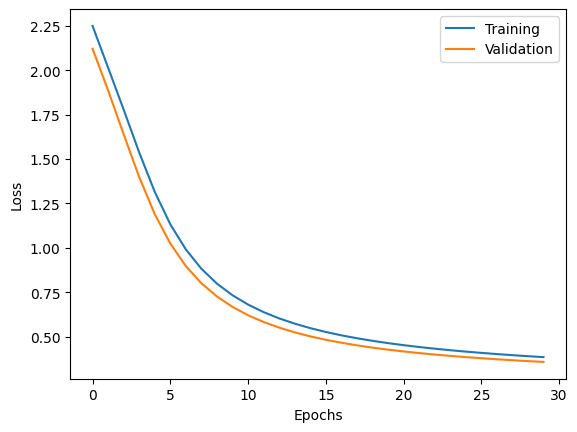

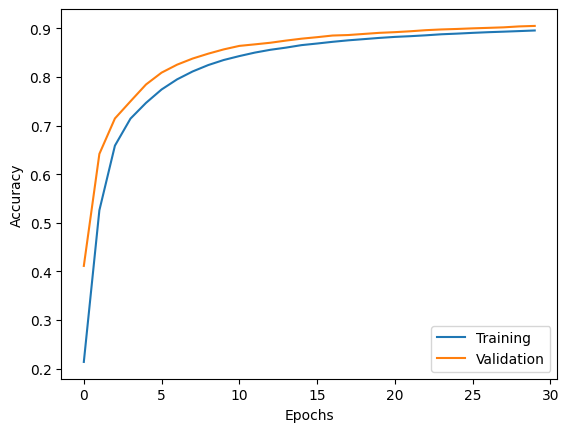

In [13]:
def plot_history(network_history):
    plt.figure()
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(network_history.history['loss'])
    plt.plot(network_history.history['val_loss'])
    plt.legend(['Training', 'Validation'])

    plt.figure()
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.plot(network_history.history['accuracy'])
    plt.plot(network_history.history['val_accuracy'])
    plt.legend(['Training', 'Validation'], loc='lower right')
    plt.show()

plot_history(network_history)

Vizsgáljuk meg a TensorBoard logokat is:

In [14]:
%load_ext tensorboard

In [15]:
%tensorboard --logdir logs

Output hidden; open in https://colab.research.google.com to view.

# Hálózat vizsgálata

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,324 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [17]:
print('Rétegek:\n')
for layer in model.layers:
    print("Réteg neve: ", layer.name, ', tanítható: ', layer.trainable)
    print(layer.get_config(),'\n')

Rétegek:

Réteg neve:  dense , tanítható:  True
{'name': 'dense', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 256, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None, 'quantization_config': None} 

Réteg neve:  dense_1 , tanítható:  True
{'name': 'dense_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 256, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': No

(np.float64(-0.5), np.float64(1822.5), np.float64(884.5), np.float64(-0.5))

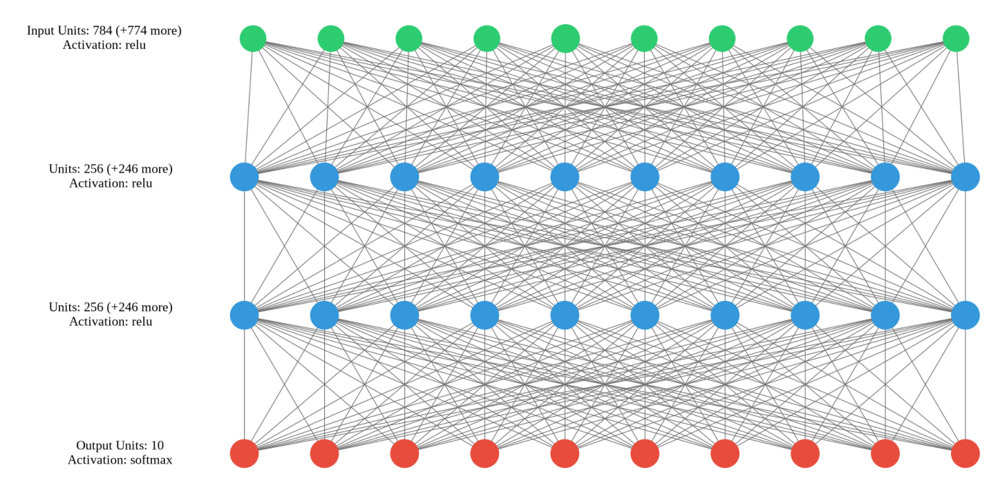

In [18]:
# keras-vizualizer segítségével láthatjuk az hálót képformátumba
!pip3 install keras-visualizer
from keras_visualizer import visualizer
import matplotlib.image as mpimg
visualizer(model, file_format='png', view=True)
img = mpimg.imread('graph.png')
fig = plt.figure(figsize=[20,9])
plt.imshow(img)
plt.axis('off')

# Predikció és tévesztési mátrix

In [19]:
preds=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [20]:
from sklearn.metrics import confusion_matrix
conf=confusion_matrix(y_test,np.argmax(preds,axis=1))

#https://scikit-learn.org/stable/modules/model_evaluation.html#confusion-matrix

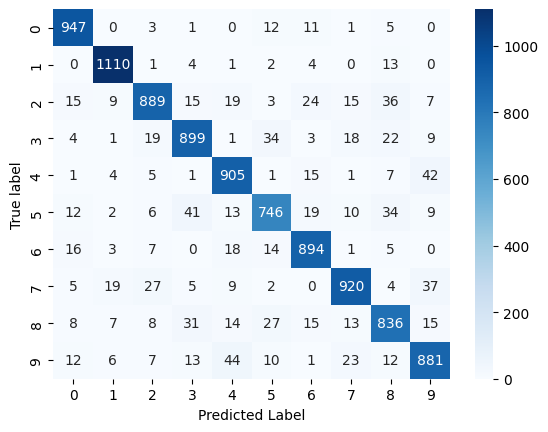

In [21]:
import seaborn as sns; #sns.set()
ax = sns.heatmap(conf, annot=True, fmt='d', cmap=plt.cm.Blues)
ax.set(xlabel='Predicted Label',
       ylabel='True label');

# Képek feltöltése Tensorboardba

In [22]:
import tensorflow as tf
logdir = "logs/images/"
file_writer = tf.summary.create_file_writer(logdir + "/mnist")
# Test névtérbe rakjuk a képeket
with tf.name_scope("Test") as scope:
  with file_writer.as_default():
    #Az első három tesztképet töltjük fel
    img = np.reshape(X_test[0:3], (-1, 28, 28, 1))
    tf.summary.image("MNIST Image 3", img, step=0,max_outputs=3,description="Info")